
# Graphic 1: Temperature Anomalies over Land and over Ocean
Replication of NASA GISS's chart of annual land and ocean temperature anomalies
(relative to 1951-1980), using GISTEMP v4 data.


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# The notebook runs from scripts/, so the repo root is one level up
ROOT = Path.cwd().parent
DATA = ROOT / "data"
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

In [4]:
columns = ["year", "land_annual", "land_lowess", "ocean_annual", "ocean_lowess"]
df = pd.read_csv(DATA / "graphic1_land_ocean.csv", skiprows=2, names=columns)
df.head()

,year,land_annual,land_lowess,ocean_annual,ocean_lowess
0,1880,-0.68,-0.55,-0.05,0.01
1,1881,-0.46,-0.58,0.01,-0.02
2,1882,-0.54,-0.61,0.00,-0.06
3,1883,-0.61,-0.64,-0.06,-0.09
4,1884,-0.78,-0.66,-0.15,-0.12


In [5]:
df = df.apply(pd.to_numeric, errors="coerce")  # non-numeric markers become NaN
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)
print(df.shape)
print(df.isna().sum())
df.describe()

(146, 5)
year            0
land_annual     0
land_lowess     0
ocean_annual    0
ocean_lowess    0
dtype: int64


,year,land_annual,land_lowess,ocean_annual,ocean_lowess
count,146.000000,146.000000,146.000000,146.000000,146.000000
mean,1952.500000,0.139795,0.142260,0.035685,0.035959
std,42.290661,0.588770,0.571881,0.310426,0.299532
min,1880.000000,-0.810000,-0.680000,-0.520000,-0.430000
25%,1916.250000,-0.267500,-0.257500,-0.205000,-0.180000
50%,1952.500000,0.020000,-0.020000,-0.040000,-0.030000
75%,1988.750000,0.402500,0.440000,0.237500,0.257500
max,2025.000000,1.900000,1.800000,0.930000,0.870000


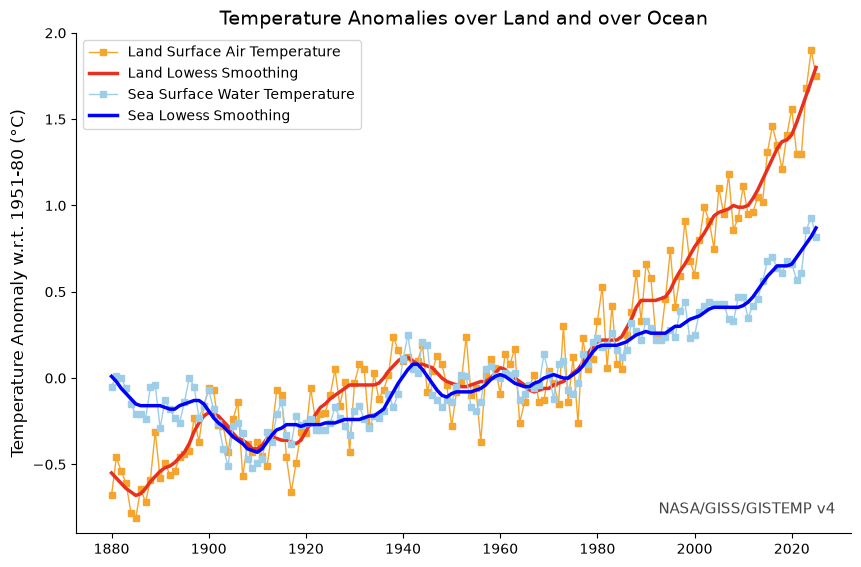

In [6]:
def plot_land_ocean(df):
    """Recreate NASA's land vs. ocean temperature anomaly chart."""
    fig, ax = plt.subplots(figsize=(10, 6.5))

    ax.plot(df["year"], df["land_annual"], color="#F5A52E", marker="s",
            markersize=4, linewidth=1, label="Land Surface Air Temperature")
    ax.plot(df["year"], df["land_lowess"], color="#E8301E", linewidth=2.5,
            label="Land Lowess Smoothing")
    ax.plot(df["year"], df["ocean_annual"], color="#9ECDE8", marker="s",
            markersize=4, linewidth=1, label="Sea Surface Water Temperature")
    ax.plot(df["year"], df["ocean_lowess"], color="#0000FF", linewidth=2.5,
            label="Sea Lowess Smoothing")

    ax.set_title("Temperature Anomalies over Land and over Ocean", fontsize=14)
    ax.set_ylabel("Temperature Anomaly w.r.t. 1951-80 (°C)", fontsize=12)
    ax.set_xticks(range(1880, 2021, 20))
    ax.set_ylim(-0.9, 2.0)
    ax.legend(loc="upper left", frameon=True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(0.98, 0.04, "NASA/GISS/GISTEMP v4", transform=ax.transAxes,
            ha="right", fontsize=11, color="#444444")
    return fig, ax


fig, ax = plot_land_ocean(df)
plt.show()

In [7]:
fig.savefig(OUT / "graphic1_land_ocean.png", dpi=300, bbox_inches="tight")
fig.savefig(OUT / "graphic1_land_ocean.pdf", bbox_inches="tight")